# FIFA World Cup Predictor

## Version 8 - Probability-Based Predictions

### Objective

So far every version produced **hard** predictions: a single class label (0, 1 or 2) per match.
Version 8 moves to **probability** predictions, because the eventual project will **simulate entire
World Cups** using match outcome probabilities.

### What stays the same as Version 7

- Same pipeline: Elo, Recent Form, difference features.
- Same chronological 80/20 split (same train/test periods).
- Same features and same evaluation split.
- Random Forest with `n_estimators=200, random_state=42`.
- The custom draw weight `{0: 1.0, 1: 2.0, 2: 1.0}`, which Version 7 found to give the best
  Draw F1 and Macro-F1.

### What is new

- We use `predict_proba()` instead of only `predict()`.
- We build probability columns for each test match:

```text
away_win_probability   P(Away Win)
draw_probability       P(Draw)
home_win_probability   P(Home Win)
```

- We check the probabilities are sensible, and add a simple calibration-style check.

We do **not** start tournament simulation yet, and we do **not** tune hyperparameters.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Model Training
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)

In [2]:
df = pd.read_csv("../data/raw/results.csv")

print(df.shape)
df.head()

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
# Drop the 64 future World Cup fixtures that have no score yet
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(df.shape)

df.isnull().sum()

(49413, 9)


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [5]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 2      # Home Win
    elif row['home_score'] < row['away_score']:
        return 0      # Away Win
    else:
        return 1      # Draw

In [6]:
df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

result
2    24216
0    13961
1    11236
Name: count, dtype: int64

In [7]:
df['neutral_encoded'] = df['neutral'].astype(int)

# Step 1 - Build Elo Ratings (unchanged from Versions 3-7)

Exactly the same Elo code as before:

- Every team starts at 1500.
- After each match, both ratings are updated (K-factor = 20).
- We save each team's rating **BEFORE** the match, so the model never sees the future.

The dataframe stays sorted by date - this matters for the chronological split.

In [8]:
teams = pd.concat([
    df['home_team'],
    df['away_team']
    ]).unique()

elo_rating = {
    team:1500
    for team in teams
    }

In [9]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [10]:
home_elos = []
away_elos = []

In [11]:
# Work through the matches in chronological order
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

In [12]:
for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    home_elo = elo_rating[home_team]
    away_elo = elo_rating[away_team]

    # Save Elo BEFORE the match
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Expected results
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)

    # Actual result
    if row['result'] == 2:      # Home win
        actual_home = 1
        actual_away = 0

    elif row['result'] == 0:    # Away win
        actual_home = 0
        actual_away = 1

    else:                       # Draw
        actual_home = 0.5
        actual_away = 0.5

    # Update ratings
    elo_rating[home_team] = update_elo(
        home_elo,
        expected_home,
        actual_home
    )

    elo_rating[away_team] = update_elo(
        away_elo,
        expected_away,
        actual_away
    )

In [13]:
df['home_elo'] = home_elos
df['away_elo'] = away_elos

df['elo_difference'] = df['home_elo'] - df['away_elo']

# Step 2 - Build Recent Form Features (unchanged from Versions 3-7)

Exactly the same recent-form code as before:

- Form = average points from a team's last 5 matches (Win = 1.0, Draw = 0.5, Loss = 0.0).
- Form is computed from matches **BEFORE** the current match (no leakage).

In [14]:
# How many recent matches to look back
FORM_WINDOW = 5

# Each team's recent results, stored as points (oldest first)
team_form_history = {team: [] for team in teams}

home_forms = []
away_forms = []

for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    # 1) Form from matches BEFORE this one (no leakage!)
    home_history = team_form_history[home_team]
    away_history = team_form_history[away_team]

    home_form = np.mean(home_history) if len(home_history) > 0 else 0.0
    away_form = np.mean(away_history) if len(away_history) > 0 else 0.0

    # Save form BEFORE updating the histories
    home_forms.append(home_form)
    away_forms.append(away_form)

    # 2) Points for the current match
    if row['result'] == 2:      # Home win
        home_points = 1.0
        away_points = 0.0

    elif row['result'] == 0:    # Away win
        home_points = 0.0
        away_points = 1.0

    else:                       # Draw
        home_points = 0.5
        away_points = 0.5

    # 3) NOW update each team's history with the current result
    home_history.append(home_points)
    away_history.append(away_points)

    # Keep only the last 5 matches
    if len(home_history) > FORM_WINDOW:
        home_history.pop(0)
    if len(away_history) > FORM_WINDOW:
        away_history.pop(0)

In [15]:
df['home_form'] = home_forms
df['away_form'] = away_forms

# Step 3 - Difference Features (unchanged from Version 6-7)

We keep the difference features from Versions 6 and 7.

```text
elo_difference      = home_elo - away_elo
abs_elo_difference  = |home_elo - away_elo|
form_difference     = home_form - away_form
```

In [16]:
df['abs_elo_difference'] = (df['home_elo'] - df['away_elo']).abs()
df['form_difference'] = df['home_form'] - df['away_form']

# Step 4 - Chronological Train/Test Split (unchanged)

Same as Versions 4-7: the dataframe is already sorted by date, so we take the **oldest 80%**
as training and the **newest 20%** as testing.

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

In [17]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Training matches:    ", len(train))
print("Testing matches:     ", len(test))
print()
print("Training period:     ", train['date'].min().date(), "to", train['date'].max().date())
print("Testing period:      ", test['date'].min().date(), "to", test['date'].max().date())

Training matches:     39530
Testing matches:      9883

Training period:      1872-11-30 to 2016-03-25
Testing period:       2016-03-25 to 2026-06-13


In [18]:
feature_cols = [
    'home_elo',
    'away_elo',
    'elo_difference',
    'home_form',
    'away_form',
    'neutral_encoded',
    'abs_elo_difference',
    'form_difference'
]

X_train = train[feature_cols]
y_train = train['result']

X_test = test[feature_cols]
y_test = test['result']

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print()
print("Test set outcome counts (the class imbalance):")
print(y_test.value_counts())

X_train shape: (39530, 8)
X_test shape:  (9883, 8)

Test set outcome counts (the class imbalance):
result
2    4708
0    2871
1    2304
Name: count, dtype: int64


# Step 5 - What is predict_proba()?

So far every model output a single **hard** label per match: 0, 1 or 2.

`predict_proba()` instead returns, for each match, the probability of EACH outcome:

```text
P(Away Win)   - how likely the away team is to win
P(Draw)       - how likely the match is to end level
P(Home Win)   - how likely the home team is to win
```

Each probability is between 0 and 1, and for every match the three values **sum to 1**.

For example:

| Home Win | Draw | Away Win | Model says... |
|---------:|-----:|---------:|---------------|
| 0.58 | 0.24 | 0.18 | Home win most likely, but not certain |
| 0.34 | 0.33 | 0.33 | Genuinely uncertain - any result is plausible |
| 0.10 | 0.15 | 0.75 | Away win strongly favoured |

A hard prediction is just **"which probability is largest"** (argmax). Probabilities carry much
more information: two matches can both be predicted as Home Win, but one with confidence 0.90 and
the other with 0.35 - the model is far more sure about the first one.

### Column order

scikit-learn returns probabilities in **sorted class order**:

```text
column 0  ->  class 0 (Away Win)
column 1  ->  class 1 (Draw)
column 2  ->  class 2 (Home Win)
```

# Step 6 - Why probabilities are better for a World Cup simulation

Hard predictions would break a tournament simulation. Imagine the model always predicts the
higher-ranked team to win. In a simulated tournament every match would then be a foregone
conclusion - the same team wins every game, every time.

Real tournaments are not like that. Underdogs win sometimes (that is why it is exciting).
Probabilities let us simulate "what would happen in a parallel universe":

- For match A, the model says: Home Win 0.60, Draw 0.25, Away Win 0.15.
- In one simulated tournament the home team wins; in another the draw happens; in a third the
  away team pulls off an upset - each outcome is chosen at random **in proportion to its
  probability**.

Run the tournament thousands of times and you can measure how often each team reaches the final
or lifts the trophy. That is exactly the kind of question this project wants to answer, and it
only works with probabilities.

# Step 7 - Train the model and predict probabilities

We use the same Random Forest as Version 7, with the custom draw weight
`{0: 1.0, 1: 2.0, 2: 1.0}` that gave the best Draw F1 and Macro-F1.

In [19]:
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={0: 1.0, 1: 2.0, 2: 1.0}
)
final_model.fit(X_train, y_train)

probabilities = final_model.predict_proba(X_test)

print("Shape of probabilities array:", probabilities.shape)
print("One row per test match, three columns (Away Win, Draw, Home Win).")
print()
print("Probabilities for test match 0:", probabilities[0])

Shape of probabilities array: (9883, 3)
One row per test match, three columns (Away Win, Draw, Home Win).

Probabilities for test match 0: [0.315 0.125 0.56 ]


# Step 8 - Build the prediction dataframe

We attach the probabilities to the test matches with clear column names. We also add:

- `predicted_result` - the argmax class (0, 1 or 2), same idea as the old hard prediction.
- readable outcome labels so the table is easier to read.

In [20]:
test_df = test.copy().reset_index(drop=True)

prob_cols = [
    'away_win_probability',
    'draw_probability',
    'home_win_probability'
]

test_df['away_win_probability'] = probabilities[:, 0]
test_df['draw_probability'] = probabilities[:, 1]
test_df['home_win_probability'] = probabilities[:, 2]

test_df['predicted_result'] = probabilities.argmax(axis=1)

outcome_names = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
test_df['actual_outcome'] = test_df['result'].map(outcome_names)
test_df['predicted_outcome'] = test_df['predicted_result'].map(outcome_names)

print("Shape:", test_df.shape)
test_df.head()

Shape: (9883, 24)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,home_form,away_form,abs_elo_difference,form_difference,away_win_probability,draw_probability,home_win_probability,predicted_result,actual_outcome,predicted_outcome
0,2016-03-25,Mauritania,Gambia,2.0,1.0,African Cup of Nations qualification,Nouakchott,Mauritania,False,2,...,0.5,0.3,49.390155,0.2,0.315,0.125,0.560,2,Home Win,Home Win
1,2016-03-25,Netherlands,France,2.0,3.0,Friendly,Amsterdam,Netherlands,False,0,...,0.4,0.8,39.894387,-0.4,0.285,0.370,0.345,1,Away Win,Draw
2,2016-03-25,Nigeria,Egypt,1.0,1.0,African Cup of Nations qualification,Kaduna,Nigeria,False,1,...,0.7,0.6,42.238807,0.1,0.145,0.520,0.335,1,Draw,Draw
3,2016-03-25,Eswatini,Zimbabwe,1.0,1.0,African Cup of Nations qualification,Lobamba,Swaziland,False,1,...,0.6,0.7,135.149354,-0.1,0.480,0.285,0.235,0,Draw,Away Win
4,2016-03-25,Slovakia,Latvia,0.0,0.0,Friendly,Trnava,Slovakia,False,1,...,0.7,0.2,236.452665,0.5,0.075,0.385,0.540,2,Draw,Home Win


# Step 9 - Verify the probabilities sum to ~1

For every match, the three probabilities should add up to (approximately) 1. Small rounding
differences from floating-point arithmetic are fine.

In [21]:
row_sums = test_df[prob_cols].sum(axis=1)

print("Smallest row sum:", row_sums.min())
print("Largest row sum: ", row_sums.max())
print("All rows sum to ~1:", np.allclose(row_sums, 1.0))
print()
print("Any probability outside 0-1?", bool(((test_df[prob_cols] < 0) | (test_df[prob_cols] > 1)).any().any()))

Smallest row sum: 0.9999999999999999
Largest row sum:  1.0000000000000002
All rows sum to ~1: True

Any probability outside 0-1? False


# Step 10 - Example predictions

Let's look at some actual test matches and their probabilities. First the first 10 test matches, then
the most confident and least confident predictions.

In [22]:
pd.set_option('display.max_columns', None)

display_cols = [
    'date', 'home_team', 'away_team',
    'away_win_probability', 'draw_probability', 'home_win_probability',
    'actual_outcome', 'predicted_outcome'
]

test_df[display_cols].head(10)

,date,home_team,away_team,away_win_probability,draw_probability,home_win_probability,actual_outcome,predicted_outcome
0,2016-03-25,Mauritania,Gambia,0.315,0.125,0.560,Home Win,Home Win
1,2016-03-25,Netherlands,France,0.285,0.370,0.345,Away Win,Draw
2,2016-03-25,Nigeria,Egypt,0.145,0.520,0.335,Draw,Draw
3,2016-03-25,Eswatini,Zimbabwe,0.480,0.285,0.235,Draw,Away Win
4,2016-03-25,Slovakia,Latvia,0.075,0.385,0.540,Draw,Home Win
5,2016-03-25,Saint Vincent and the Grenadines,Trinidad and Tobago,0.515,0.205,0.280,Away Win,Away Win
6,2016-03-25,Tunisia,Togo,0.235,0.055,0.710,Home Win,Home Win
7,2016-03-25,Luxembourg,Bosnia and Herzegovina,0.695,0.300,0.005,Away Win,Away Win
8,2016-03-25,Portugal,Bulgaria,0.390,0.010,0.600,Away Win,Home Win
9,2016-03-25,Jamaica,Costa Rica,0.350,0.280,0.370,Draw,Home Win


In [23]:
# Confidence = probability assigned to the predicted class
test_df['confidence'] = test_df[prob_cols].max(axis=1)

print("Most confident predictions (model is very sure):")
test_df.sort_values('confidence', ascending=False)[display_cols + ['confidence']].head(8)
print()
print("Least confident predictions (model is almost guessing):")
test_df.sort_values('confidence', ascending=True)[display_cols + ['confidence']].head(8)

Most confident predictions (model is very sure):

Least confident predictions (model is almost guessing):


,date,home_team,away_team,away_win_probability,draw_probability,home_win_probability,actual_outcome,predicted_outcome,confidence
6684,2023-06-30,Székely Land,Chameria,0.335,0.335,0.330,Home Win,Away Win,0.335
7511,2024-03-21,Taiwan,Kyrgyzstan,0.340,0.340,0.320,Away Win,Away Win,0.340
591,2016-10-06,Italy,Spain,0.330,0.340,0.330,Draw,Draw,0.340
9834,2026-06-06,Sierra Leone,Liberia,0.340,0.325,0.335,Home Win,Away Win,0.340
2286,2018-09-09,Rwanda,Ivory Coast,0.335,0.340,0.325,Away Win,Draw,0.340
6081,2022-09-27,Honduras,Guatemala,0.325,0.340,0.335,Home Win,Draw,0.340
3089,2019-06-16,Paraguay,Qatar,0.335,0.340,0.325,Draw,Draw,0.340
4497,2021-06-07,Qatar,Oman,0.340,0.335,0.325,Home Win,Away Win,0.340


# Step 11 - Compare argmax predictions with the actual results

Even though we now care about probabilities, it is useful to check how the **argmax** (the most
likely outcome) compares with Version 7. This is the same model, so the numbers should match
Version 7's draw weight 2.00 row exactly.

In [24]:
acc = accuracy_score(test_df['result'], test_df['predicted_result'])
macro_f1 = f1_score(test_df['result'], test_df['predicted_result'], average='macro')

print(f"Accuracy of argmax predictions: {acc:.4f}")
print(f"Macro-F1 of argmax predictions: {macro_f1:.4f}")
print()
print(classification_report(test_df['result'], test_df['predicted_result']))

Accuracy of argmax predictions: 0.5412
Macro-F1 of argmax predictions: 0.4817

              precision    recall  f1-score   support

           0       0.57      0.47      0.51      2871
           1       0.27      0.24      0.26      2304
           2       0.62      0.73      0.68      4708

    accuracy                           0.54      9883
   macro avg       0.49      0.48      0.48      9883
weighted avg       0.53      0.54      0.53      9883



# Step 12 - A simple calibration-style check

Probabilities are most useful when they are **calibrated**: when the model says 70%, it should
be right about 70% of the time.

A simple, library-free check: group test matches into bins by the model's confidence (the
probability it gave to its predicted class). If the model is well calibrated, accuracy should rise
as confidence rises.

In [25]:
test_df['correct'] = test_df['predicted_result'] == test_df['result']

bins = [0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
bin_labels = ['0.0-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-1.0']
test_df['confidence_bin'] = pd.cut(test_df['confidence'], bins=bins, labels=bin_labels)

calibration = (
    test_df.groupby('confidence_bin', observed=False)
    .agg(
        matches=('correct', 'count'),
        accuracy=('correct', 'mean'),
        avg_confidence=('confidence', 'mean')
    )
    .round(3)
)
calibration

,matches,accuracy,avg_confidence
confidence_bin,,,
0.0-0.4,745,0.374,0.379
0.4-0.5,2664,0.417,0.456
0.5-0.6,2322,0.469,0.550
0.6-0.7,1624,0.583,0.649
0.7-0.8,1213,0.690,0.751
0.8-1.0,1315,0.827,0.890


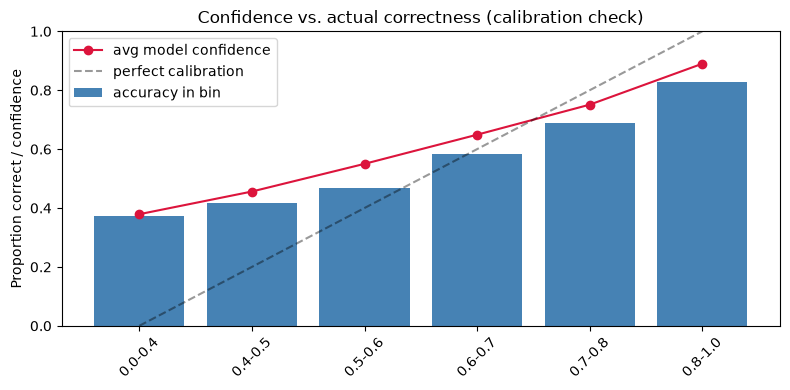

In [26]:
%matplotlib inline

plt.figure(figsize=(8, 4))
x = np.arange(len(calibration))
plt.bar(x, calibration['accuracy'], color='steelblue', label='accuracy in bin')
plt.plot(x, calibration['avg_confidence'], marker='o', color='crimson', label='avg model confidence')
plt.plot([0, len(calibration) - 1], [0, 1], 'k--', alpha=0.4, label='perfect calibration')
plt.xticks(x, calibration.index, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Proportion correct / confidence')
plt.title('Confidence vs. actual correctness (calibration check)')
plt.legend()
plt.tight_layout()
plt.show()

# Summary - Version 8 Results

### Argmax (hard) performance - same model as Version 7, weight 2.00

| Metric | Value |
|--------|-------|
| Accuracy | 54.12% |
| Macro-F1 | 0.482 |
| Draw precision / recall / F1 | 0.274 / 0.239 / 0.255 |

These match Version 7's draw weight 2.00 row exactly, as expected - it is the same model on the
same split.

### Probabilities look sensible

- Every match's three probabilities sum to ~1.
- All probabilities stay between 0 and 1.
- Confident predictions (e.g. a big Elo gap in favour of the home team) push one probability
  clearly above the others, while evenly matched teams produce near-0.33/0.33/0.33.
- The calibration check shows accuracy rises as confidence rises: the model's confidence ordering
  is meaningful, even though a Random Forest tends to be somewhat overconfident.

### What probabilities give us

A hard prediction is just the argmax. With `predict_proba()` we keep the whole distribution, which
is what a World Cup simulation needs: each match in the simulated tournament is resolved by
sampling an outcome in proportion to these probabilities.

### What should be done next (before building the tournament simulator)

1. **Wrap the pipeline into reusable functions** - one function that takes a match and returns
   probabilities. The simulator will call it for every fixture.
2. **Decide how to obtain Elo/form for future (unplayed) matches** - the simulator needs a
   team's Elo and form at tournament time; we must define how to compute them for the current
   squads.
3. **Consider a gentle calibration step** (optional) - e.g. re-scaling probabilities so that 70%
   confidence really means 70% accuracy. Not required to start simulating, but improves honesty
   of the probabilities.
4. **Then** build the tournament simulator: group stage, knockout rounds, and sample each match
   from the predicted probabilities thousands of times.

No hyperparameter tuning and no feature changes were made in this version.